<a href="https://colab.research.google.com/github/medikartpharmaatpune-blip/b2b-file-processor/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Dataset shape:", x_train.shape)

Dataset shape: (60000, 28, 28)


In [ ]:
x_train = x_train.astype("float32")

# Normalize from [0,255] to [-1,1]
x_train = (x_train - 127.5) / 127.5

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [ ]:
x_train = np.expand_dims(x_train, axis=-1)

print("New shape:", x_train.shape)

New shape: (60000, 28, 28, 1)


In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)

print("Dataset ready!")

Dataset ready!


In [ ]:
LATENT_DIM = 400

generator = tf.keras.Sequential([

    # Input: random noise vector
    tf.keras.layers.Input(shape=(LATENT_DIM,)),

    # Convert 100 numbers into 7x7x256
    tf.keras.layers.Dense(7 * 7 * 256, use_bias=False),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    # Reshape into image-like format
    tf.keras.layers.Reshape((7, 7, 256)),

    # 7x7 -> 14x14
    tf.keras.layers.Conv2DTranspose(
        128,
        kernel_size=5,
        strides=1,
        padding="same",
        use_bias=False
    ),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    # 14x14 -> 28x28
    tf.keras.layers.Conv2DTranspose(
        64,
        kernel_size=5,
        strides=2,
        padding="same",
        use_bias=False
    ),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    # Final grayscale image
    tf.keras.layers.Conv2DTranspose(
        1,
        kernel_size=5,
        strides=2,
        padding="same",
        activation="tanh"
    )
])

generator.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12544)          │     5,017,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,094,145 (23.25 MB)

 Trainable params: 6,068,673 (23.15 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
noise = tf.random.normal([1, LATENT_DIM])

generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


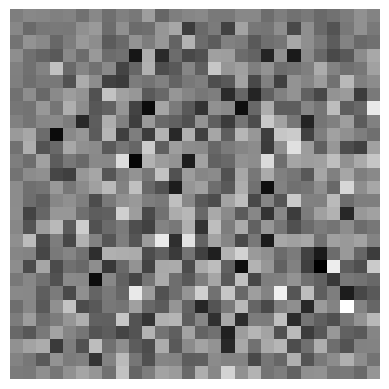

In [ ]:
plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
discriminator = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=5,
        strides=2,
        padding="same"
    ),

    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        128,
        kernel_size=5,
        strides=2,
        padding="same"
    ),

    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),

    # Output one value
    tf.keras.layers.Dense(1)
])

discriminator.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Take one real image
real_image = x_train[0:1]

# Ask discriminator to classify it
prediction = discriminator(
    real_image,
    training=False
)

print("Discriminator output:", prediction.numpy())

Discriminator output: [[0.00689821]]


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

In [ ]:
def generator_loss(fake_output):
    """
    Generator wants the discriminator
    to classify fake images as REAL (1).
    """

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

In [ ]:
def discriminator_loss(real_output, fake_output):
    """
    Discriminator:
    Real images -> 1
    Fake images -> 0
    """

    # Loss for real images
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    # Loss for fake images
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    # Total discriminator loss
    total_loss = real_loss + fake_loss

    return total_loss

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.4
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.4
)

print("Optimizers created.")

Optimizers created.


In [ ]:
NUM_EXAMPLES = 16

seed = tf.random.normal(
    [NUM_EXAMPLES, LATENT_DIM]
)

print("Seed shape:", seed.shape)

Seed shape: (16, 400)


In [ ]:
@tf.function
def train_step(images):

    # -----------------------------------------
    # 1. Create random noise
    # -----------------------------------------

    noise = tf.random.normal(
        [BATCH_SIZE, LATENT_DIM]
    )

    # -----------------------------------------
    # 2. Record operations for gradients
    # -----------------------------------------

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # -----------------------------------------
        # Generator creates fake images
        # -----------------------------------------

        generated_images = generator(
            noise,
            training=True
        )

        # -----------------------------------------
        # Discriminator checks real images
        # -----------------------------------------

        real_output = discriminator(
            images,
            training=True
        )

        # -----------------------------------------
        # Discriminator checks fake images
        # -----------------------------------------

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # -----------------------------------------
        # Calculate Generator loss
        # -----------------------------------------

        gen_loss = generator_loss(
            fake_output
        )

        # -----------------------------------------
        # Calculate Discriminator loss
        # -----------------------------------------

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # -----------------------------------------
    # 3. Calculate Generator gradients
    # -----------------------------------------

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    # -----------------------------------------
    # 4. Calculate Discriminator gradients
    # -----------------------------------------

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # -----------------------------------------
    # 5. Update Generator weights
    # -----------------------------------------

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    # -----------------------------------------
    # 6. Update Discriminator weights
    # -----------------------------------------

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [ ]:
def generate_and_show_images(
    model,
    epoch,
    test_input
):

    # Generate images
    predictions = model(
        test_input,
        training=False
    )

    # Create figure
    fig = plt.figure(
        figsize=(6, 6)
    )

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        # Convert [-1,1] back to [0,1]
        image = predictions[i, :, :, 0] * 0.5 + 0.5

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch}"
    )

    plt.show()

Epoch 1/30 | Generator Loss: 0.8525 | Discriminator Loss: 1.2466


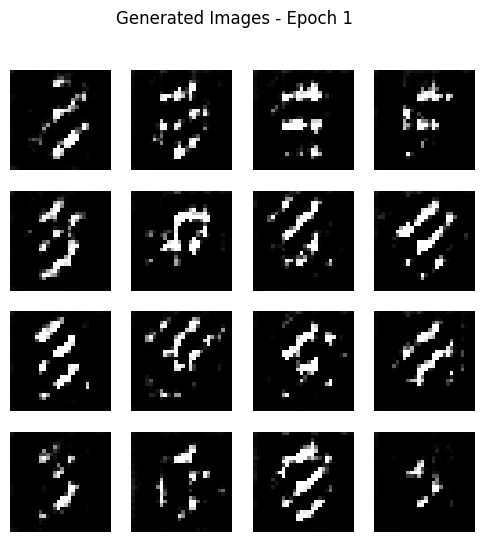

Epoch 2/30 | Generator Loss: 0.9376 | Discriminator Loss: 1.2320


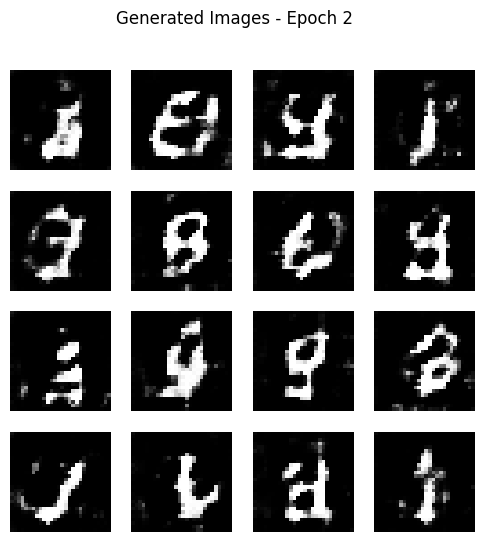

Epoch 3/30 | Generator Loss: 1.0703 | Discriminator Loss: 1.1484


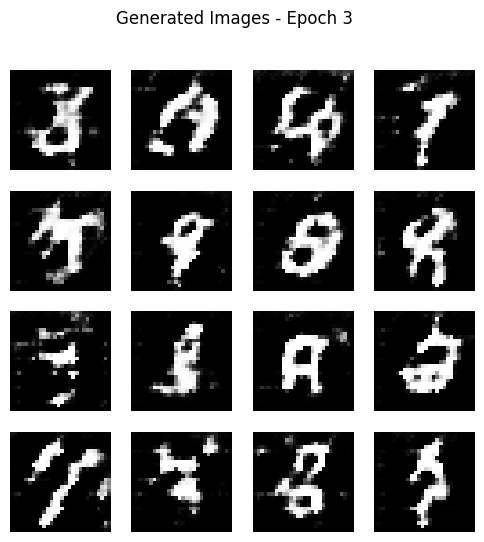

Epoch 4/30 | Generator Loss: 1.1351 | Discriminator Loss: 1.1219


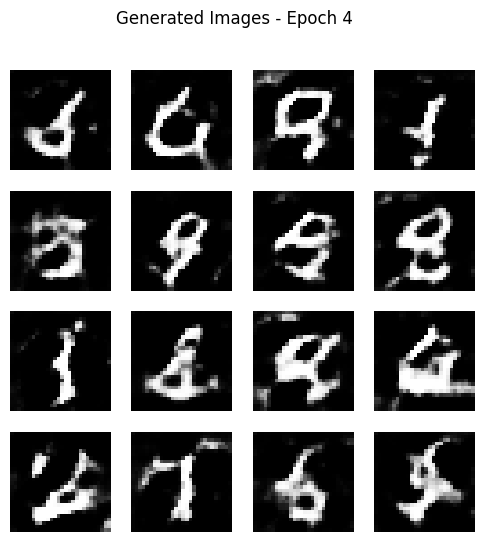

Epoch 5/30 | Generator Loss: 1.1093 | Discriminator Loss: 1.1477


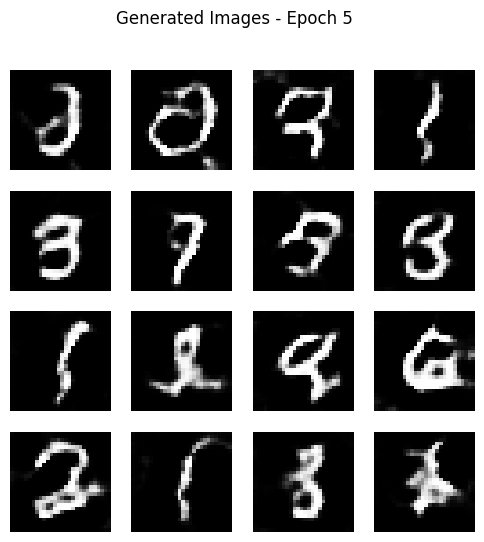

Epoch 6/30 | Generator Loss: 1.0654 | Discriminator Loss: 1.1853


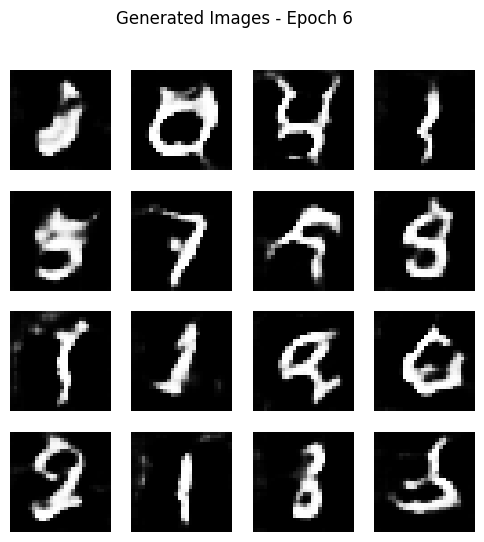

Epoch 7/30 | Generator Loss: 1.0148 | Discriminator Loss: 1.1897


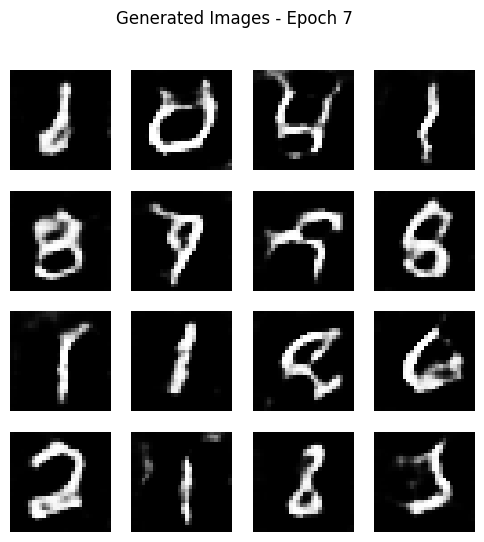

Epoch 8/30 | Generator Loss: 1.0386 | Discriminator Loss: 1.1823


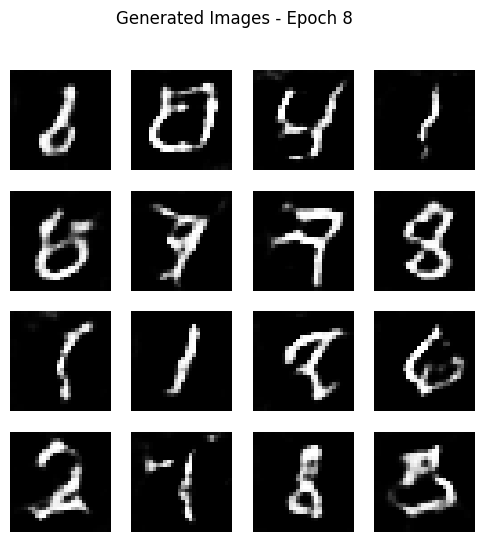

Epoch 9/30 | Generator Loss: 1.0378 | Discriminator Loss: 1.1830


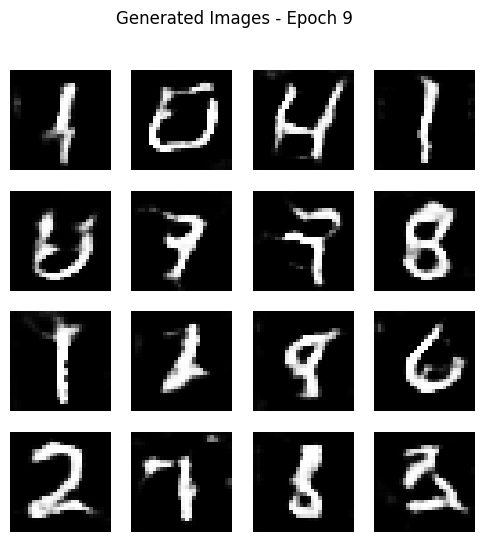

Epoch 10/30 | Generator Loss: 1.0732 | Discriminator Loss: 1.1805


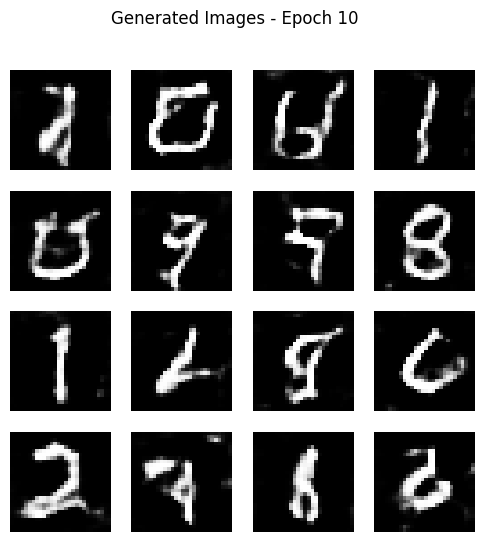

Epoch 11/30 | Generator Loss: 1.0444 | Discriminator Loss: 1.1857


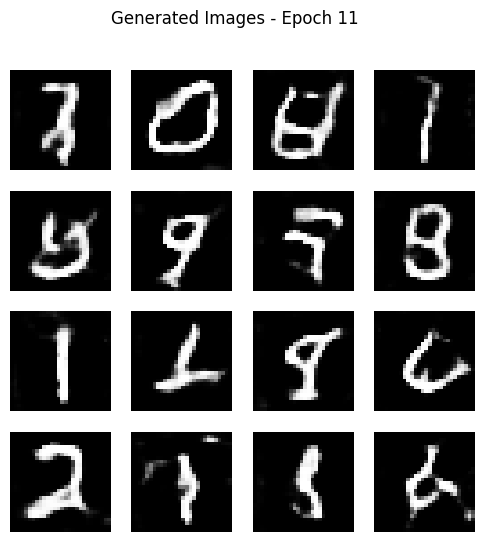

Epoch 12/30 | Generator Loss: 1.0756 | Discriminator Loss: 1.1825


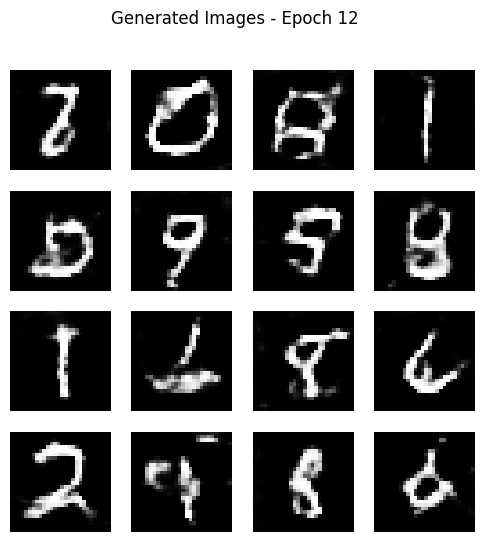

Epoch 13/30 | Generator Loss: 1.1430 | Discriminator Loss: 1.4637


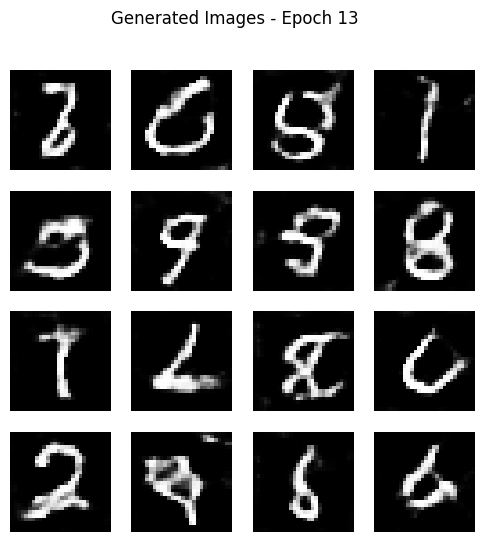

Epoch 14/30 | Generator Loss: 0.9963 | Discriminator Loss: 1.2013


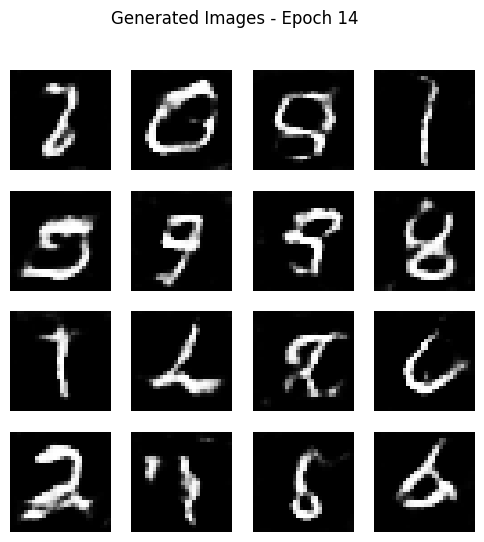

Epoch 15/30 | Generator Loss: 1.0189 | Discriminator Loss: 1.1911


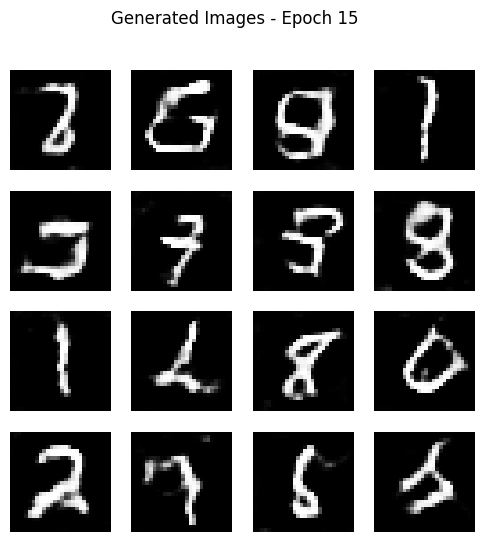

Epoch 16/30 | Generator Loss: 1.0166 | Discriminator Loss: 1.1949


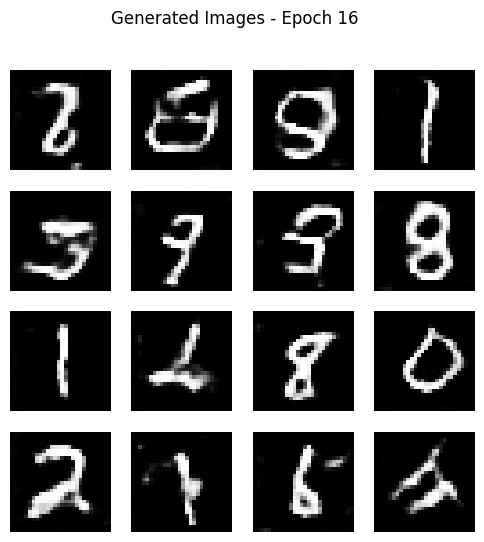

Epoch 17/30 | Generator Loss: 1.0374 | Discriminator Loss: 1.1956


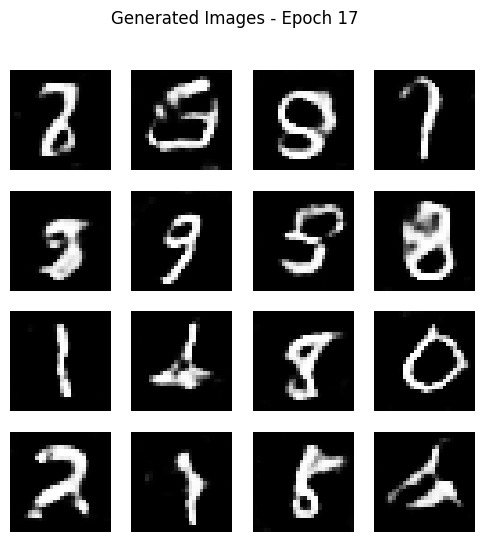

Epoch 18/30 | Generator Loss: 1.0238 | Discriminator Loss: 1.2018


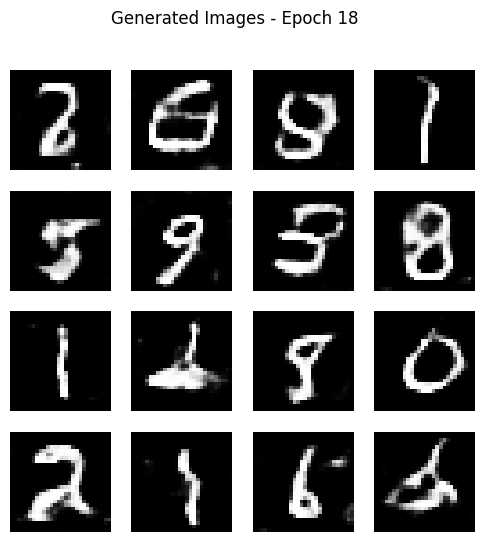

Epoch 19/30 | Generator Loss: 1.0309 | Discriminator Loss: 1.2003


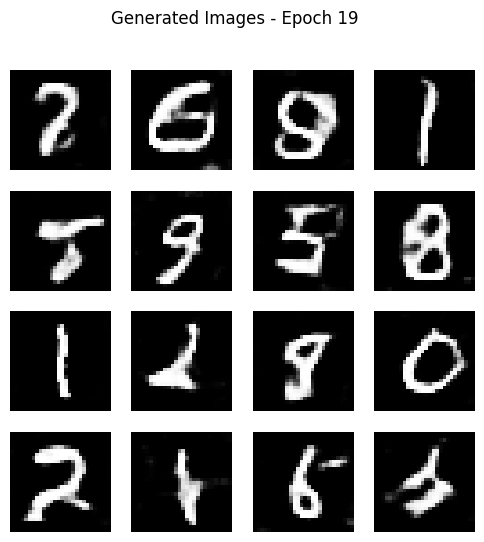

Epoch 20/30 | Generator Loss: 1.0318 | Discriminator Loss: 1.2102


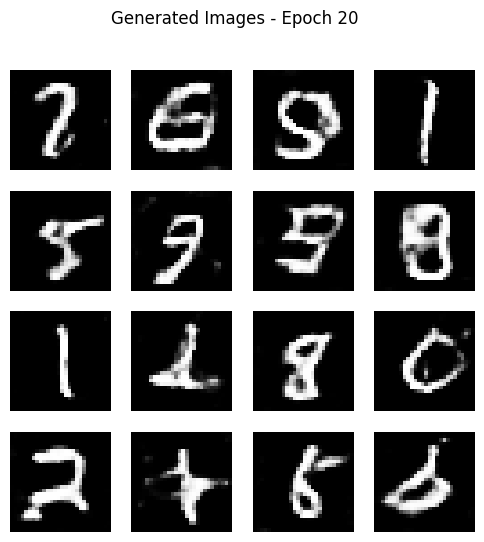

Epoch 21/30 | Generator Loss: 1.0164 | Discriminator Loss: 1.2111


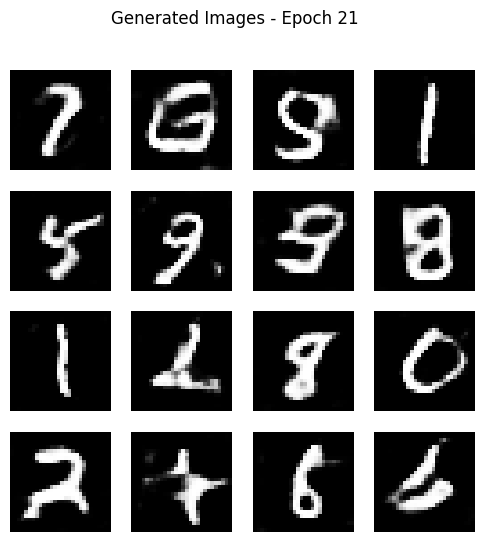

Epoch 22/30 | Generator Loss: 1.0188 | Discriminator Loss: 1.2190


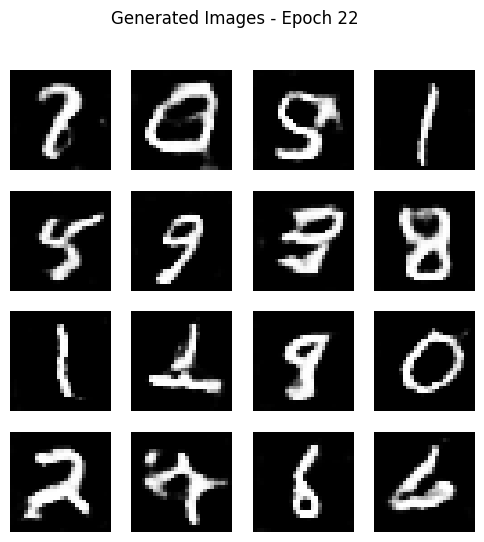

Epoch 23/30 | Generator Loss: 1.0253 | Discriminator Loss: 1.2446


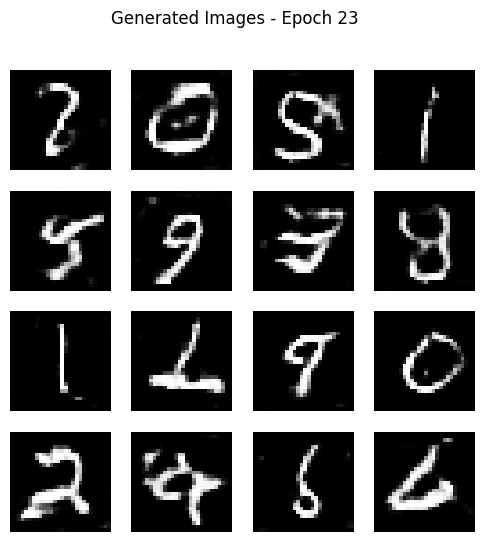

Epoch 24/30 | Generator Loss: 1.0041 | Discriminator Loss: 1.2106


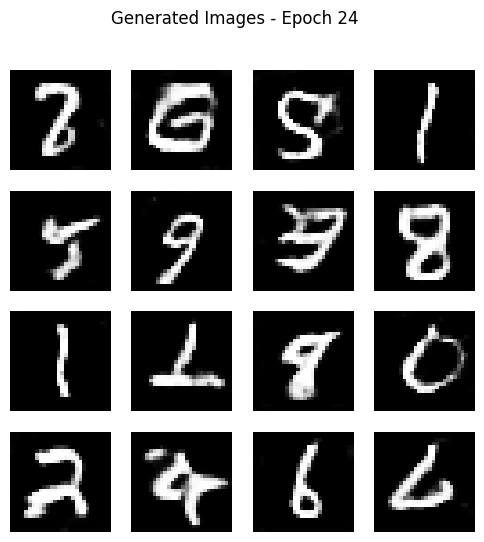

Epoch 25/30 | Generator Loss: 0.9947 | Discriminator Loss: 1.2272


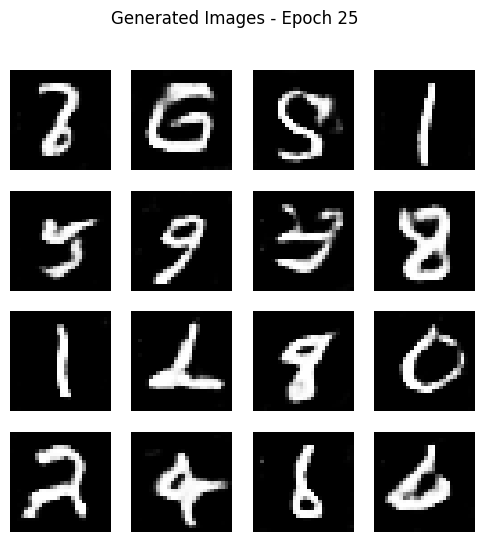

Epoch 26/30 | Generator Loss: 0.9855 | Discriminator Loss: 1.2345


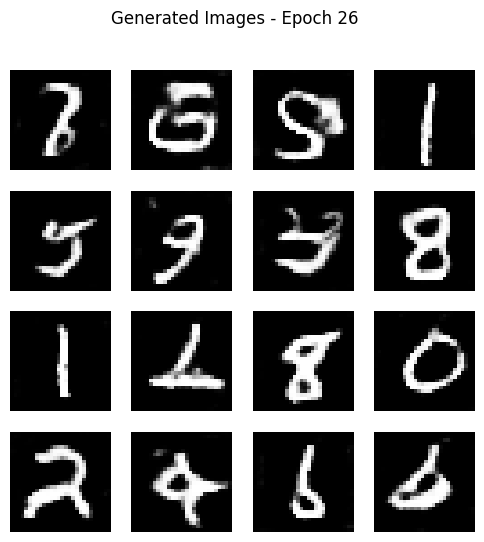

Epoch 27/30 | Generator Loss: 0.9871 | Discriminator Loss: 1.2343


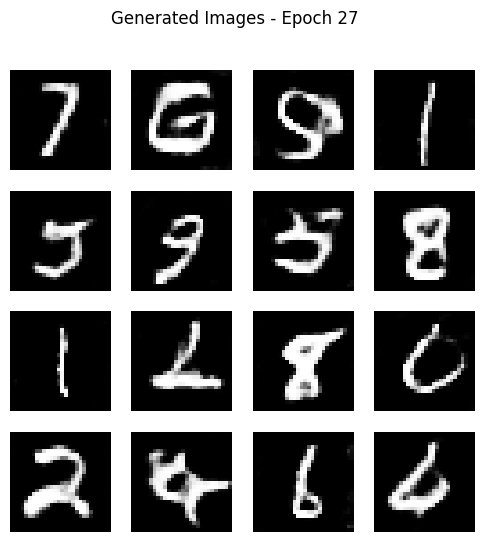

Epoch 28/30 | Generator Loss: 0.9960 | Discriminator Loss: 1.2371


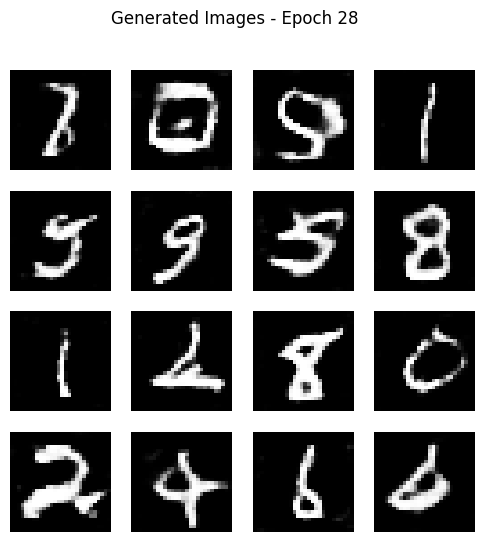

Epoch 29/30 | Generator Loss: 0.9567 | Discriminator Loss: 1.2465


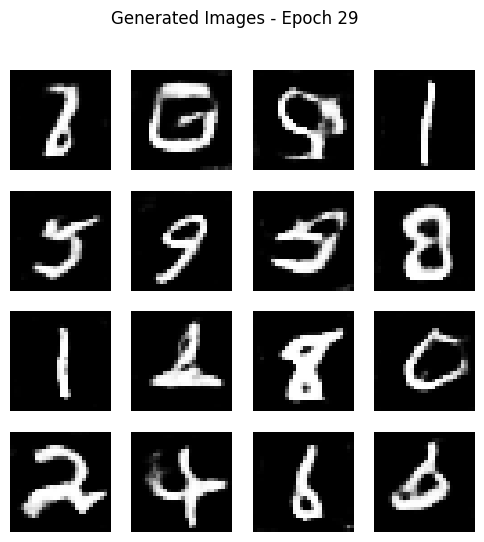

Epoch 30/30 | Generator Loss: 0.9708 | Discriminator Loss: 1.2471


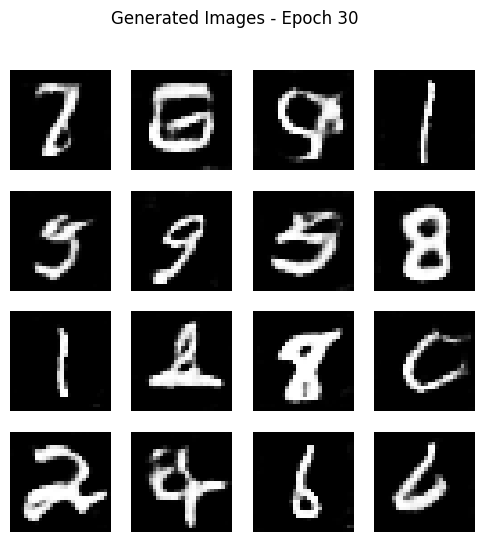

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):

    total_gen_loss = 0.0
    total_disc_loss = 0.0
    batch_count = 0

    # -----------------------------------------
    # Train using every batch
    # -----------------------------------------

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        total_gen_loss += gen_loss
        total_disc_loss += disc_loss

        batch_count += 1

    # -----------------------------------------
    # Average losses
    # -----------------------------------------

    average_gen_loss = (
        total_gen_loss / batch_count
    )

    average_disc_loss = (
        total_disc_loss / batch_count
    )

    # -----------------------------------------
    # Print losses
    # -----------------------------------------

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {average_gen_loss:.4f} | "
        f"Discriminator Loss: {average_disc_loss:.4f}"
    )

    # -----------------------------------------
    # Show generated images
    # -----------------------------------------

    generate_and_show_images(
        generator,
        epoch + 1,
        seed
    )